# Base-model bake-off (macro-F1)

Goal: pick the best **base encoder** for the `no / yes / unclear` crime axis. We fine-tune each candidate **head-only** (fast, fair), then rank by **macro-F1** on a held-out split.

Auto-detects CUDA (NVIDIA Windows) / MPS (Apple Silicon) / CPU — same code, no edits.

**Setup (run once at project root):**
```bash
uv sync
uv run python -m ipykernel install --user --name crimellm --display-name "CrimeLLM (uv)"
```

## What is macro-F1?

**F1 per class** = harmonic mean of precision and recall for that class:

$$F1 = \frac{2 \cdot P \cdot R}{P + R}$$

**Macro-F1** = plain average of per-class F1s, ignoring class size:

$$macroF1 = \frac{F1_{no} + F1_{yes} + F1_{unclear}}{3}$$

### Why not accuracy?

Your classes are imbalanced — `unclear` is usually the smallest. A lazy model that always predicts the majority class looks fine on accuracy but is useless. Example: 70 `no`, 25 `yes`, 5 `unclear`, model always predicts `no`:

| metric | value |
|--------|------|
| accuracy | 0.70 (misleading) |
| F1_no | ~0.82 |
| F1_yes / F1_unclear | 0 |
| **macro-F1** | **0.27** (reveals the truth) |

Macro-F1 treats every class equally → forces the model to actually learn minorities. Range: 0 (worst) → 1 (perfect).

## 1. Environment

In [1]:
import sys, platform, time
from pathlib import Path
import torch, numpy as np, pandas as pd
from crimellm import resolve_device, Config, train, load_dataset_from_csv, load_sample_dataset

info = resolve_device()
print(f"Python : {sys.version.split()[0]}")
print(f"Torch  : {torch.__version__}")
print(f"OS     : {platform.system()} {platform.machine()}")
print(f"Device : {info}")

Python : 3.11.14
Torch  : 2.12.0
OS     : Darwin arm64
Device : mps:Apple Silicon (arm64) (fp16=False, bf16=False)


## 2. Data

Uses `data/sample.csv` if present (tiny smoke set), otherwise the built-in sample. Replace with your real labeled CSV for meaningful results.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
csv_path = PROJECT_ROOT / "data" / "sample.csv"
splits = load_dataset_from_csv(csv_path) if csv_path.exists() else load_sample_dataset()
print(splits)

Casting the dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
})


## 3. Candidate models

| model | params | arch | domain | notes |
|-------|-------:|------|--------|-------|
| `distilbert-base-uncased` | 66M | DistilBERT | general English | fastest baseline |
| `roberta-base` | 125M | RoBERTa | general English | strong general-text default |
| `microsoft/deberta-v3-base` | 184M | DeBERTa v3 | general English | usually top on small/medium data |
| `nlpaueb/legal-bert-base-uncased` | 110M | BERT | US/EU/UK legal text | good for legal-prose memories |
| `law-ai/InLegalBERT` | 110M | BERT | Indian statutory text | strong only if Indian-law-flavored |

**For multilingual / Danish memories** add `xlm-roberta-base` (270M) or `microsoft/mdeberta-v3-base` (278M).

Comment models in/out as you like.

In [3]:
CANDIDATES = [
    "distilbert-base-uncased",
    "roberta-base",
    "microsoft/deberta-v3-base",
    "nlpaueb/legal-bert-base-uncased",
    "law-ai/InLegalBERT",
]

# Head-only fine-tune. Bump epochs / LR since only the linear head trains.
BASE_CFG = dict(
    freeze_encoder=True,
    num_train_epochs=15,
    learning_rate=5e-4,
    train_batch_size=8,
    eval_batch_size=16,
    max_len=256,
)

## 4. Train each candidate, collect metrics

For each model: head-only train → eval → compute **macro-F1**, **accuracy**, **per-class F1**, **wall-time**.

First run downloads each base model (a few hundred MB each). Subsequent runs use the HF cache.

In [4]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

id2label = Config().id2label
label_names = [id2label[i] for i in range(len(id2label))]
rows = []
reports = {}

for name in CANDIDATES:
    print(f"\n=== {name} ===")
    cfg = Config(
        model_name=name,
        output_dir=str(PROJECT_ROOT / "runs" / name.replace('/', '__')),
        **BASE_CFG,
    )
    t0 = time.time()
    try:
        result = train(splits, cfg)
    except Exception as e:
        print(f"  SKIP ({type(e).__name__}: {e})")
        rows.append({"model": name, "macro_f1": None, "accuracy": None, "sec": None, "error": str(e)[:80]})
        continue
    elapsed = time.time() - t0

    # Per-class metrics from raw predictions
    pred_out = result.trainer.predict(result.trainer.eval_dataset)
    y_true = pred_out.label_ids
    y_pred = np.argmax(pred_out.predictions, axis=-1)

    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    per_class = f1_score(y_true, y_pred, average=None, labels=list(range(len(label_names))), zero_division=0)
    reports[name] = classification_report(y_true, y_pred, target_names=label_names, zero_division=0)

    row = {"model": name, "macro_f1": round(float(macro), 4), "accuracy": round(float(acc), 4), "sec": round(elapsed, 1)}
    for lbl, v in zip(label_names, per_class):
        row[f"f1_{lbl}"] = round(float(v), 4)
    rows.append(row)
    print(f"  macro_f1={row['macro_f1']}  acc={row['accuracy']}  ({elapsed:.1f}s)")


=== distilbert-base-uncased ===
[crimellm] device: mps:Apple Silicon (arm64) (fp16=False, bf16=False)


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
No log,1.150749,15,0.250000,0.133333


[crimellm] final eval: {'eval_loss': 1.1507487297058105, 'eval_accuracy': 0.25, 'eval_macro_f1': 0.13333333333333333}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  macro_f1=0.1333  acc=0.25  (18.9s)


## 5. Leaderboard

In [5]:
df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False, na_position="last").reset_index(drop=True)
df

,model,macro_f1,accuracy,sec,f1_no,f1_yes,f1_unclear
0,distilbert-base-uncased,0.5000,0.50,10.9,0.5000,0.0000,1.0000
1,roberta-base,0.4444,0.50,61.3,0.6667,0.0000,0.6667
2,nlpaueb/legal-bert-base-uncased,0.3889,0.50,15.6,0.5000,0.6667,0.0000
3,microsoft/deberta-v3-base,0.2222,0.50,58.5,0.0000,0.6667,0.0000
4,law-ai/InLegalBERT,0.1333,0.25,18.9,0.0000,0.0000,0.4000


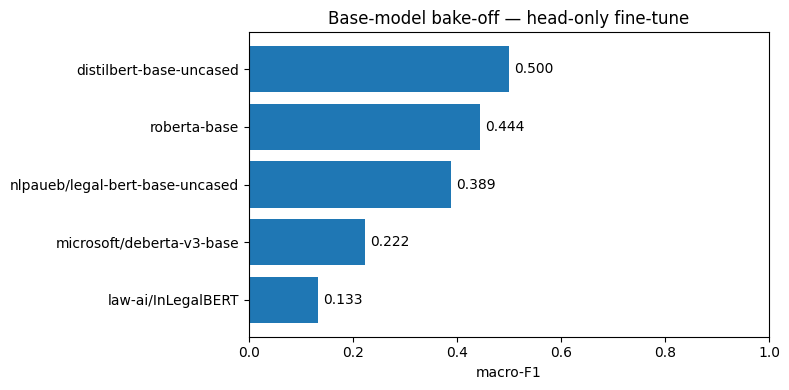

In [6]:
import matplotlib.pyplot as plt

plot_df = df.dropna(subset=["macro_f1"])
fig, ax = plt.subplots(figsize=(8, 0.6 * len(plot_df) + 1))
ax.barh(plot_df["model"], plot_df["macro_f1"])
ax.invert_yaxis()
ax.set_xlabel("macro-F1")
ax.set_xlim(0, 1)
ax.set_title("Base-model bake-off — head-only fine-tune")
for i, v in enumerate(plot_df["macro_f1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

## 6. Per-class breakdown (winner)

In [7]:
winner = df.iloc[0]["model"]
print(f"Winner: {winner}\n")
print(reports[winner])

Winner: distilbert-base-uncased

              precision    recall  f1-score   support

          no       0.33      1.00      0.50         1
         yes       0.00      0.00      0.00         2
     unclear       1.00      1.00      1.00         1

    accuracy                           0.50         4
   macro avg       0.44      0.67      0.50         4
weighted avg       0.33      0.50      0.38         4



## Notes & next steps

- **Toy data warning:** with the 12-row sample, ranks are noise. Macro-F1 here mostly says "pipeline runs". Re-run with hundreds-to-thousands of real labels for a meaningful ranking.
- **Head-only is a fair fast comparison.** The winner here is the encoder whose pretrained representations already separate `crime / no-crime / unclear` best. After picking the winner, re-train it with `freeze_encoder=False` for the final model — usually +5–15 macro-F1 with enough data.
- **Want full fine-tune in the bake-off?** Set `BASE_CFG['freeze_encoder']=False`, drop `learning_rate` to `2e-5`, `num_train_epochs=4`. Much slower, but more representative of final performance.
- **Statistical noise:** with small eval splits, repeat with different `seed`s and average — otherwise a 1-sample flip changes the ranking.